# ESM GO-split Checkpoint Error Analysis

This notebook performs error analysis for the three namespace-specific ESM MLP checkpoints:

- `esm_BPO_tuned.pt`
- `esm_CCO_tuned.pt`
- `esm_MFO_tuned.pt`

It follows the GO-split setup from `ESM_GO_split_tuning.ipynb`.

This notebook does **not** retrain the models.  
It only reloads saved checkpoints, runs validation inference, and analyzes errors.

If you want to analyze the baseline models instead, change the `CHECKPOINTS` dictionary to:

```python
CHECKPOINTS = {
    "BPO": "esm_BPO_baseline.pt",
    "CCO": "esm_CCO_baseline.pt",
    "MFO": "esm_MFO_baseline.pt",
}
```

## Step 0. Imports and Paths

In [2]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import load_npz

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

DATA_DIR = "data_processed_esm"
KMER_DATA_DIR = "data_processed_kmer"

# Default: analyze tuned GO-split ESM models
CHECKPOINTS = {
    "BPO": "pt/esm_BPO_tuned.pt",
    "CCO": "pt/esm_CCO_tuned.pt",
    "MFO": "pt/esm_MFO_tuned.pt",
}

# If you want baseline instead, use:
# CHECKPOINTS = {
#     "BPO": "esm_BPO_baseline.pt",
#     "CCO": "esm_CCO_baseline.pt",
#     "MFO": "esm_MFO_baseline.pt",
# }

OUTPUT_DIR = "esm_error_analysis_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("DATA_DIR:", DATA_DIR)
print("KMER_DATA_DIR:", KMER_DATA_DIR)
print("CHECKPOINTS:", CHECKPOINTS)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_DIR: data_processed_esm
KMER_DATA_DIR: data_processed_kmer
CHECKPOINTS: {'BPO': 'pt/esm_BPO_tuned.pt', 'CCO': 'pt/esm_CCO_tuned.pt', 'MFO': 'pt/esm_MFO_tuned.pt'}
OUTPUT_DIR: esm_error_analysis_outputs


## Step 1. Load Processed ESM Embeddings and Labels

### Why this step?
The `.pt` checkpoint only stores model weights.  
To evaluate errors, we need the ESM validation embeddings and the corresponding GO labels.

We reuse the same `train_idx.npy` and `val_idx.npy` from the k-mer pipeline so that comparisons remain aligned across k-mer and ESM experiments.

In [3]:
X_esm = np.load(os.path.join(DATA_DIR, "X_esm.npy"))
print("X_esm:", X_esm.shape, X_esm.dtype)

y_sparse_path = os.path.join(DATA_DIR, "Y_sparse.npz")
y_dense_path = os.path.join(DATA_DIR, "Y.npy")

if os.path.exists(y_sparse_path):
    Y = load_npz(y_sparse_path)
    print("Loaded sparse Y:", Y.shape, type(Y))
elif os.path.exists(y_dense_path):
    Y = np.load(y_dense_path)
    print("Loaded dense Y:", Y.shape, type(Y))
else:
    raise FileNotFoundError("Cannot find Y_sparse.npz or Y.npy in data_processed_esm")

train_idx = np.load(os.path.join(KMER_DATA_DIR, "train_idx.npy"))
val_idx = np.load(os.path.join(KMER_DATA_DIR, "val_idx.npy"))

X_train = X_esm[train_idx]
X_val = X_esm[val_idx]

if hasattr(Y, "tocsr"):
    Y_train = Y[train_idx]
    Y_val = Y[val_idx]
else:
    Y_train = Y[train_idx]
    Y_val = Y[val_idx]

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("Y_train:", Y_train.shape)
print("Y_val:  ", Y_val.shape)

assert X_val.shape[0] == Y_val.shape[0]

X_esm: (140569, 640) float32
Loaded sparse Y: (140569, 31454) <class 'scipy.sparse._csr.csr_matrix'>
X_train: (112455, 640)
X_val:   (28114, 640)
Y_train: (112455, 31454)
Y_val:   (28114, 31454)


## Step 2. Standardize ESM Features

### Why this step?
The ESM GO-split training notebook standardized the embeddings using training-set statistics.  
We must repeat the same transformation before loading the trained checkpoint.

If you already saved `esm_scaler.pkl`, this cell will load it.  
Otherwise, it fits a scaler on `X_train` and applies it to `X_val`.

In [4]:
scaler_path = "esm_scaler.pkl"

if os.path.exists(scaler_path):
    with open(scaler_path, "rb") as f:
        scaler = pickle.load(f)
    X_train = scaler.transform(X_train).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    print("Loaded existing scaler from:", scaler_path)
else:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_val = scaler.transform(X_val).astype(np.float32)
    with open(scaler_path, "wb") as f:
        pickle.dump(scaler, f)
    print("Fitted and saved scaler to:", scaler_path)

print("Standardized X_train:", X_train.shape, X_train.dtype)
print("Standardized X_val:  ", X_val.shape, X_val.dtype)

Loaded existing scaler from: esm_scaler.pkl
Standardized X_train: (112455, 640) float32
Standardized X_val:   (28114, 640) float32


## Step 3. Load GO Term Order

### Why this step?
To split labels into BPO / CCO / MFO, we need to know which GO term each column of `Y` represents.

For the ESM pipeline, this is usually stored in `mlb.pkl`.

In [5]:
mlb_path = os.path.join(DATA_DIR, "mlb.pkl")

if os.path.exists(mlb_path):
    with open(mlb_path, "rb") as f:
        mlb = pickle.load(f)
    go_terms = list(mlb.classes_)
    print("Loaded GO terms from mlb.pkl")
else:
    meta_path = os.path.join(DATA_DIR, "meta.pkl")
    if os.path.exists(meta_path):
        with open(meta_path, "rb") as f:
            meta = pickle.load(f)

        if isinstance(meta, dict) and "go_terms" in meta:
            go_terms = meta["go_terms"].tolist() if hasattr(meta["go_terms"], "tolist") else list(meta["go_terms"])
            print("Loaded GO terms from meta['go_terms']")
        elif hasattr(meta, "classes_"):
            go_terms = list(meta.classes_)
            print("Loaded GO terms from meta.classes_")
        else:
            raise KeyError("Could not find GO term order in meta.pkl")
    else:
        raise FileNotFoundError("Could not find mlb.pkl or meta.pkl in data_processed_esm")

print("Number of GO terms:", len(go_terms))
print("Y columns:", Y_val.shape[1])
assert len(go_terms) == Y_val.shape[1]

Loaded GO terms from mlb.pkl
Number of GO terms: 31454
Y columns: 31454


## Step 4. Load GO Namespace Mapping

### Why this step?
The GO-split models were trained separately for:
- BPO
- CCO
- MFO

We reconstruct the same column splits using `train_terms.tsv`.

In [6]:
TERMS_PATH = os.path.join("..", "cafa-5-protein-function-prediction", "Train", "train_terms.tsv")

if not os.path.exists(TERMS_PATH):
    raise FileNotFoundError(
        f"Cannot find train_terms.tsv at {TERMS_PATH}. "
        "Please update TERMS_PATH."
    )

terms_df = pd.read_csv(TERMS_PATH, sep="\t")

go_to_aspect = (
    terms_df[["term", "aspect"]]
    .drop_duplicates()
    .set_index("term")["aspect"]
    .to_dict()
)

bpo_idx = [i for i, go in enumerate(go_terms) if go_to_aspect.get(go) == "BPO"]
cco_idx = [i for i, go in enumerate(go_terms) if go_to_aspect.get(go) == "CCO"]
mfo_idx = [i for i, go in enumerate(go_terms) if go_to_aspect.get(go) == "MFO"]

namespace_indices = {
    "BPO": bpo_idx,
    "CCO": cco_idx,
    "MFO": mfo_idx,
}

namespace_go_terms = {
    "BPO": [go_terms[i] for i in bpo_idx],
    "CCO": [go_terms[i] for i in cco_idx],
    "MFO": [go_terms[i] for i in mfo_idx],
}

print("Total GO terms:", len(go_terms))
print("BPO labels:", len(bpo_idx))
print("CCO labels:", len(cco_idx))
print("MFO labels:", len(mfo_idx))
print("Check total:", len(bpo_idx) + len(cco_idx) + len(mfo_idx))

Total GO terms: 31454
BPO labels: 21279
CCO labels: 2957
MFO labels: 7218
Check total: 31454


## Step 5. Split Validation Labels by Namespace

In [7]:
Y_val_namespace = {
    "BPO": Y_val[:, bpo_idx],
    "CCO": Y_val[:, cco_idx],
    "MFO": Y_val[:, mfo_idx],
}

Y_train_namespace = {
    "BPO": Y_train[:, bpo_idx],
    "CCO": Y_train[:, cco_idx],
    "MFO": Y_train[:, mfo_idx],
}

for ns in ["BPO", "CCO", "MFO"]:
    print(ns, "Y_train:", Y_train_namespace[ns].shape, "Y_val:", Y_val_namespace[ns].shape)

BPO Y_train: (112455, 21279) Y_val: (28114, 21279)
CCO Y_train: (112455, 2957) Y_val: (28114, 2957)
MFO Y_train: (112455, 7218) Y_val: (28114, 7218)


## Step 6. Define ESM Dataset and MLP Architecture

### Why this step?
Each `.pt` checkpoint stores model weights only, so we rebuild the same ESM MLP architecture before loading each checkpoint.

In [8]:
class ProteinESMDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X.astype(np.float32)
        self.Y = Y
        self.is_sparse = hasattr(Y, "tocsr")
        if self.is_sparse:
            self.Y = Y.tocsr()
            self.n_labels = self.Y.shape[1]

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = torch.from_numpy(self.X[idx])

        if self.is_sparse:
            start = self.Y.indptr[idx]
            end = self.Y.indptr[idx + 1]
            pos_idx = self.Y.indices[start:end]

            y = torch.zeros(self.n_labels, dtype=torch.float32)
            y[pos_idx] = 1.0
        else:
            y = torch.tensor(self.Y[idx], dtype=torch.float32)

        return x, y


class ESMMLP(nn.Module):
    def __init__(self, input_dim, output_dim, hidden1=512, hidden2=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, output_dim)
        )

    def forward(self, x):
        return self.net(x)


def build_val_loader(X_val, Y_val_ns, batch_size=64):
    dataset = ProteinESMDataset(X_val, Y_val_ns)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=torch.cuda.is_available()
    )
    return dataset, loader


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_val.shape[1]

print("Device:", device)
print("input_dim:", input_dim)

Device: cpu
input_dim: 640


/global/home/users/yushanfu/esm_env/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Step 7. Load Checkpoint and Infer Architecture

### Why this step?
If the saved model uses hidden sizes different from the default, we infer the hidden dimensions from the checkpoint weight shapes.

In [9]:
def load_checkpoint_state_dict(path):
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Checkpoint not found: {path}. "
            "Please make sure the .pt file is in the current directory."
        )

    checkpoint = torch.load(path, map_location="cpu")

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        return checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict):
        return checkpoint
    else:
        raise ValueError("Unsupported checkpoint format.")


def infer_mlp_dims_from_state_dict(state_dict):
    if "net.0.weight" in state_dict and "net.4.weight" in state_dict:
        hidden1 = state_dict["net.0.weight"].shape[0]
        hidden2 = state_dict["net.4.weight"].shape[0]
    else:
        linear_weight_keys = [
            k for k in state_dict.keys()
            if k.endswith("weight") and len(state_dict[k].shape) == 2
        ]
        print("Detected linear-like weight keys:")
        for k in linear_weight_keys:
            print(k, tuple(state_dict[k].shape))

        hidden1 = state_dict[linear_weight_keys[0]].shape[0]
        hidden2 = state_dict[linear_weight_keys[1]].shape[0]

    return int(hidden1), int(hidden2)


def build_model_from_checkpoint(checkpoint_path, input_dim, output_dim, device, dropout=0.3):
    state_dict = load_checkpoint_state_dict(checkpoint_path)
    hidden1, hidden2 = infer_mlp_dims_from_state_dict(state_dict)

    model = ESMMLP(
        input_dim=input_dim,
        output_dim=output_dim,
        hidden1=hidden1,
        hidden2=hidden2,
        dropout=dropout
    ).to(device)

    model.load_state_dict(state_dict)
    model.eval()

    return model, {"hidden1": hidden1, "hidden2": hidden2, "dropout": dropout}

## Step 8. Run Validation Inference for Each Namespace

### Why this step?
We only need a forward pass through the validation set.  
No training is performed here.

In [10]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs = []
    all_targets = []

    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device, non_blocking=True)
        logits = model(X_batch)
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.append(probs)
        all_targets.append(Y_batch.numpy())

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_targets)

    return y_prob, y_true


predictions = {}
model_configs = {}

for ns in ["BPO", "CCO", "MFO"]:
    print("=" * 80)
    print(f"Loading and evaluating {ns}")
    print("=" * 80)

    _, val_loader = build_val_loader(X_val, Y_val_namespace[ns], batch_size=64)

    model, inferred_config = build_model_from_checkpoint(
        checkpoint_path=CHECKPOINTS[ns],
        input_dim=input_dim,
        output_dim=Y_val_namespace[ns].shape[1],
        device=device,
        dropout=0.3
    )

    y_prob, y_true = get_predictions(model, val_loader, device)

    predictions[ns] = {
        "y_prob": y_prob,
        "y_true": y_true,
    }

    model_configs[ns] = inferred_config

    np.save(os.path.join(OUTPUT_DIR, f"{ns}_y_prob.npy"), y_prob)
    np.save(os.path.join(OUTPUT_DIR, f"{ns}_y_true.npy"), y_true)

    print(ns, "y_prob:", y_prob.shape, "y_true:", y_true.shape)
    print(ns, "inferred config:", inferred_config)

Loading and evaluating BPO
BPO y_prob: (28114, 21279) y_true: (28114, 21279)
BPO inferred config: {'hidden1': 1024, 'hidden2': 512, 'dropout': 0.3}
Loading and evaluating CCO
CCO y_prob: (28114, 2957) y_true: (28114, 2957)
CCO inferred config: {'hidden1': 1024, 'hidden2': 512, 'dropout': 0.3}
Loading and evaluating MFO
MFO y_prob: (28114, 7218) y_true: (28114, 7218)
MFO inferred config: {'hidden1': 1024, 'hidden2': 512, 'dropout': 0.3}


## Step 9. Threshold Selection

### Why this step?
Error analysis requires binary predictions.  

If you already know the best thresholds from your previous ESM GO-split notebook, fill them in `BEST_THRESHOLDS`.

If you leave a value as `None`, the notebook will re-run threshold sweeping for that namespace.

In [11]:
# Fill in your known thresholds here if you already have them.
# Example:
# BEST_THRESHOLDS = {"BPO": 0.75, "CCO": 0.65, "MFO": 0.85}

BEST_THRESHOLDS = {
    "BPO": None,
    "CCO": None,
    "MFO": None,
}


def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.95, 0.05)

    records = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)
        micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        records.append({
            "threshold": float(t),
            "micro_f1": float(micro),
            "macro_f1": float(macro),
        })

    best_micro = max(records, key=lambda x: x["micro_f1"])
    best_macro = max(records, key=lambda x: x["macro_f1"])

    return records, best_micro, best_macro


threshold_results = {}

for ns in ["BPO", "CCO", "MFO"]:
    y_prob = predictions[ns]["y_prob"]
    y_true = predictions[ns]["y_true"]

    if BEST_THRESHOLDS[ns] is not None:
        selected_threshold = float(BEST_THRESHOLDS[ns])
        y_pred = (y_prob >= selected_threshold).astype(np.int8)
        micro = f1_score(y_true, y_pred, average="micro", zero_division=0)
        macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

        threshold_results[ns] = {
            "records": None,
            "best_micro": {
                "threshold": selected_threshold,
                "micro_f1": float(micro),
                "macro_f1": float(macro),
            },
            "best_macro": None,
            "selected_threshold": selected_threshold,
        }

        print("=" * 80)
        print(ns)
        print("Using provided threshold:", selected_threshold)
        print("micro-F1:", micro)
        print("macro-F1:", macro)

    else:
        records, best_micro, best_macro = threshold_sweep(y_true, y_prob)

        threshold_results[ns] = {
            "records": records,
            "best_micro": best_micro,
            "best_macro": best_macro,
            "selected_threshold": best_micro["threshold"],
        }

        print("=" * 80)
        print(ns)
        print("Best micro:", best_micro)
        print("Best macro:", best_macro)

        pd.DataFrame(records).to_csv(
            os.path.join(OUTPUT_DIR, f"{ns}_threshold_sweep.csv"),
            index=False
        )

BPO
Best micro: {'threshold': 0.8, 'micro_f1': 0.1843773452426078, 'macro_f1': 0.04060551508860181}
Best macro: {'threshold': 0.6500000000000001, 'micro_f1': 0.1535613996421071, 'macro_f1': 0.044144412197699004}
CCO
Best micro: {'threshold': 0.6500000000000001, 'micro_f1': 0.2628795657284716, 'macro_f1': 0.07836417271972405}
Best macro: {'threshold': 0.7500000000000001, 'micro_f1': 0.2506882613587432, 'macro_f1': 0.08315604591051522}
MFO
Best micro: {'threshold': 0.9000000000000001, 'micro_f1': 0.2850332752862512, 'macro_f1': 0.09184794198637769}
Best macro: {'threshold': 0.8, 'micro_f1': 0.25901231625129023, 'macro_f1': 0.11046465335130193}


## Step 10. Compute FP / FN / TP Error Summary

In [12]:
def compute_error_analysis_for_namespace(ns, y_true, y_prob, threshold, go_terms_ns):
    y_pred = (y_prob >= threshold).astype(np.int8)

    fp = (y_pred == 1) & (y_true == 0)
    fn = (y_pred == 0) & (y_true == 1)
    tp = (y_pred == 1) & (y_true == 1)

    fp_per_label = fp.sum(axis=0)
    fn_per_label = fn.sum(axis=0)
    tp_per_label = tp.sum(axis=0)

    true_count_per_label = y_true.sum(axis=0)
    pred_count_per_label = y_pred.sum(axis=0)

    summary = {
        "namespace": ns,
        "threshold": float(threshold),
        "total_tp": int(tp.sum()),
        "total_fp": int(fp.sum()),
        "total_fn": int(fn.sum()),
        "total_true_labels": int(y_true.sum()),
        "total_predicted_labels": int(y_pred.sum()),
        "avg_true_labels_per_protein": float(y_true.sum(axis=1).mean()),
        "avg_predicted_labels_per_protein": float(y_pred.sum(axis=1).mean()),
    }

    label_error_df = pd.DataFrame({
        "namespace": ns,
        "go_term": go_terms_ns,
        "true_count": true_count_per_label,
        "pred_count": pred_count_per_label,
        "tp": tp_per_label,
        "fp": fp_per_label,
        "fn": fn_per_label,
    })

    label_error_df["fn_rate"] = label_error_df["fn"] / (label_error_df["true_count"] + 1e-12)
    label_error_df["fp_rate"] = label_error_df["fp"] / (label_error_df["pred_count"] + 1e-12)

    return summary, label_error_df


error_summaries = []
label_error_tables = {}

for ns in ["BPO", "CCO", "MFO"]:
    y_true = predictions[ns]["y_true"]
    y_prob = predictions[ns]["y_prob"]
    threshold = threshold_results[ns]["selected_threshold"]

    summary, label_error_df = compute_error_analysis_for_namespace(
        ns=ns,
        y_true=y_true,
        y_prob=y_prob,
        threshold=threshold,
        go_terms_ns=namespace_go_terms[ns],
    )

    error_summaries.append(summary)
    label_error_tables[ns] = label_error_df

    label_error_df.to_csv(
        os.path.join(OUTPUT_DIR, f"{ns}_per_label_error_table.csv"),
        index=False
    )

error_summary_df = pd.DataFrame(error_summaries)
display(error_summary_df)

error_summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "namespace_error_summary.csv"),
    index=False
)

,namespace,threshold,total_tp,total_fp,total_fn,total_true_labels,total_predicted_labels,avg_true_labels_per_protein,avg_predicted_labels_per_protein
0,BPO,0.80,181189,1094857,508180,689369,1276046,24.520489,45.388276
1,CCO,0.65,137871,672665,100522,238393,810536,8.479512,28.830334
2,MFO,0.90,40838,112345,92528,133366,153183,4.743758,5.448638


## Step 11. Plot Error Counts by Namespace

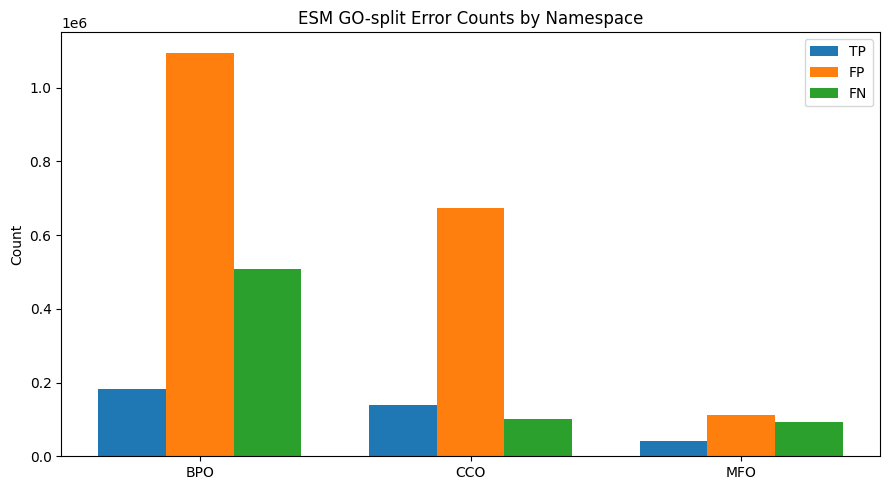

In [13]:
x = np.arange(len(error_summary_df))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, error_summary_df["total_tp"], width=width, label="TP")
plt.bar(x, error_summary_df["total_fp"], width=width, label="FP")
plt.bar(x + width, error_summary_df["total_fn"], width=width, label="FN")

plt.xticks(x, error_summary_df["namespace"])
plt.ylabel("Count")
plt.title("ESM GO-split Error Counts by Namespace")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "namespace_error_counts.png"), dpi=200, bbox_inches="tight")
plt.show()

## Step 12. Top False Negative GO Terms

### Interpretation
False negatives are GO terms that are truly present but missed by the model.

In [14]:
for ns in ["BPO", "CCO", "MFO"]:
    print("=" * 80)
    print(f"Top False Negative GO terms: {ns}")
    print("=" * 80)

    top_fn = (
        label_error_tables[ns][label_error_tables[ns]["true_count"] > 0]
        .sort_values("fn", ascending=False)
        .head(15)
    )

    display(top_fn[["go_term", "true_count", "pred_count", "tp", "fn", "fn_rate"]])

    top_fn.to_csv(
        os.path.join(OUTPUT_DIR, f"{ns}_top_false_negative_terms.csv"),
        index=False
    )

Top False Negative GO terms: BPO


,go_term,true_count,pred_count,tp,fn,fn_rate
2653,GO:0008150,18271.0,2701,2353,15918,0.871217
3304,GO:0009987,12184.0,15,9,12175,0.999261
13362,GO:0065007,8153.0,744,541,7612,0.933644
11212,GO:0050789,7699.0,886,641,7058,0.916742
11216,GO:0050794,6617.0,1129,718,5899,0.891492
11286,GO:0050896,6144.0,523,319,5825,0.948079
2654,GO:0008152,6106.0,1773,1060,5046,0.826400
14224,GO:0071704,5657.0,1984,1136,4521,0.799187
6472,GO:0032501,5663.0,2262,1380,4283,0.756313
9330,GO:0044238,4882.0,1238,672,4210,0.862351


Top False Negative GO terms: CCO


,go_term,true_count,pred_count,tp,fn,fn_rate
212,GO:0005622,14098.0,8136,6175,7923,0.561995
1554,GO:0043226,12103.0,7878,5482,6621,0.547054
176,GO:0005575,18430.0,15564,11840,6590,0.357569
278,GO:0005737,10686.0,5937,4113,6573,0.615104
2550,GO:0110165,18117.0,15287,11560,6557,0.361925
1555,GO:0043227,11030.0,7251,4796,6234,0.565186
1557,GO:0043229,11617.0,7888,5421,6196,0.533356
1559,GO:0043231,10425.0,7351,4814,5611,0.538225
217,GO:0005634,5737.0,7150,3587,2150,0.374760
348,GO:0005829,3685.0,4766,1576,2109,0.572320


Top False Negative GO terms: MFO


,go_term,true_count,pred_count,tp,fn,fn_rate
275,GO:0003674,15626.0,1,1,15625,0.999936
1409,GO:0005488,11462.0,0,0,11462,1.000000
1421,GO:0005515,9625.0,0,0,9625,1.000000
320,GO:0003824,4961.0,997,682,4279,0.862528
6337,GO:0097159,2523.0,945,437,2086,0.826793
6994,GO:1901363,2481.0,960,445,2036,0.820637
276,GO:0003676,1989.0,1442,620,1369,0.688286
2694,GO:0016740,1959.0,1273,719,1240,0.632976
4283,GO:0042802,1134.0,1,1,1133,0.999118
4346,GO:0043167,1083.0,168,57,1026,0.947368


## Step 13. Top False Positive GO Terms

### Interpretation
False positives are GO terms predicted by the model but not present in the ground truth.

In [15]:
for ns in ["BPO", "CCO", "MFO"]:
    print("=" * 80)
    print(f"Top False Positive GO terms: {ns}")
    print("=" * 80)

    top_fp = (
        label_error_tables[ns][label_error_tables[ns]["pred_count"] > 0]
        .sort_values("fp", ascending=False)
        .head(15)
    )

    display(top_fp[["go_term", "true_count", "pred_count", "tp", "fp", "fp_rate"]])

    top_fp.to_csv(
        os.path.join(OUTPUT_DIR, f"{ns}_top_false_positive_terms.csv"),
        index=False
    )

Top False Positive GO terms: BPO


,go_term,true_count,pred_count,tp,fp,fp_rate
9354,GO:0044283,537.0,3007,411,2596,0.863319
10262,GO:0046394,339.0,2763,253,2510,0.908433
4457,GO:0016053,342.0,2749,254,2495,0.907603
17337,GO:1901566,1030.0,2854,583,2271,0.795725
4589,GO:0016477,504.0,2462,272,2190,0.889521
10992,GO:0048729,569.0,2437,293,2144,0.879770
17359,GO:1901615,365.0,2322,208,2114,0.910422
1511,GO:0006082,891.0,2709,625,2084,0.769288
5149,GO:0019752,845.0,2681,597,2084,0.777322
9079,GO:0043436,887.0,2685,616,2069,0.770577


Top False Positive GO terms: CCO


,go_term,true_count,pred_count,tp,fp,fp_rate
683,GO:0016604,301.0,5526,226,5300,0.959102
1936,GO:0070062,441.0,5229,311,4918,0.940524
274,GO:0005730,659.0,5317,481,4836,0.909535
1799,GO:0048471,238.0,4886,126,4760,0.974212
1050,GO:0031981,2673.0,6395,1764,4631,0.724159
1667,GO:0044297,329.0,4798,199,4599,0.958524
1558,GO:0043230,471.0,4888,317,4571,0.935147
226,GO:0005654,2054.0,5955,1384,4571,0.767590
1928,GO:0065010,470.0,4887,317,4570,0.935134
1561,GO:0043233,3145.0,6479,1916,4563,0.704275


Top False Positive GO terms: MFO


,go_term,true_count,pred_count,tp,fp,fp_rate
131,GO:0001067,570.0,1657,406,1251,0.754979
106,GO:0000976,568.0,1632,402,1230,0.753676
291,GO:0003700,581.0,1653,460,1193,0.721718
7190,GO:1990837,657.0,1637,457,1180,0.720831
285,GO:0003690,741.0,1630,461,1169,0.717178
4048,GO:0035639,235.0,1258,132,1126,0.895072
111,GO:0000987,210.0,1265,147,1118,0.883794
107,GO:0000977,246.0,1290,189,1101,0.853488
4398,GO:0043565,871.0,1652,584,1068,0.646489
6764,GO:0140110,760.0,1441,441,1000,0.693963


## Step 14. Label Frequency vs False Negative Rate

### Why this step?
GO terms with fewer positive examples are usually harder to predict.  
This plot checks whether rare labels have higher false negative rates.

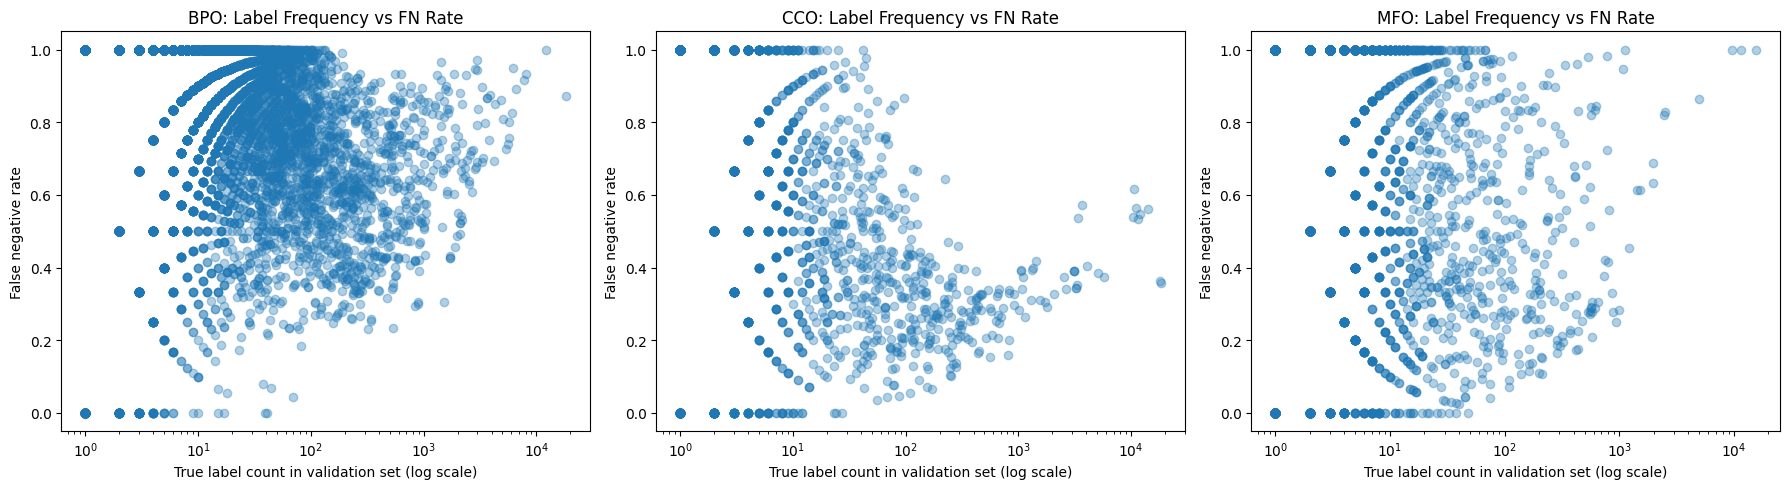

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ns in zip(axes, ["BPO", "CCO", "MFO"]):
    plot_df = label_error_tables[ns].copy()
    plot_df = plot_df[plot_df["true_count"] > 0]

    ax.scatter(plot_df["true_count"], plot_df["fn_rate"], alpha=0.35)
    ax.set_xscale("log")
    ax.set_xlabel("True label count in validation set (log scale)")
    ax.set_ylabel("False negative rate")
    ax.set_title(f"{ns}: Label Frequency vs FN Rate")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "label_frequency_vs_fn_rate_by_namespace.png"), dpi=200, bbox_inches="tight")
plt.show()

## Step 15. Predicted vs True GO Count Distribution by Namespace

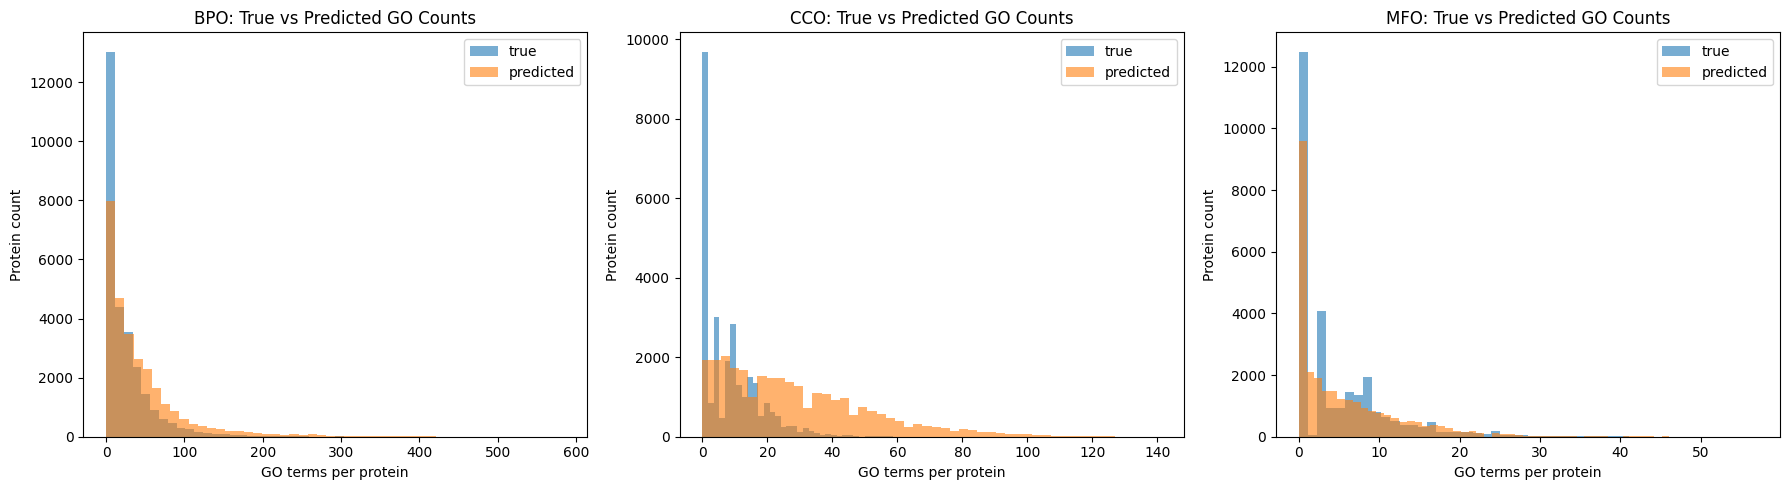

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, ns in zip(axes, ["BPO", "CCO", "MFO"]):
    y_true = predictions[ns]["y_true"]
    y_prob = predictions[ns]["y_prob"]
    threshold = threshold_results[ns]["selected_threshold"]
    y_pred = (y_prob >= threshold).astype(np.int8)

    true_counts = y_true.sum(axis=1)
    pred_counts = y_pred.sum(axis=1)

    ax.hist(true_counts, bins=50, alpha=0.6, label="true")
    ax.hist(pred_counts, bins=50, alpha=0.6, label="predicted")
    ax.set_title(f"{ns}: True vs Predicted GO Counts")
    ax.set_xlabel("GO terms per protein")
    ax.set_ylabel("Protein count")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "true_vs_predicted_go_count_by_namespace.png"), dpi=200, bbox_inches="tight")
plt.show()

## Step 16. Save Combined Error Table

In [18]:
combined_label_error_df = pd.concat(
    [label_error_tables[ns] for ns in ["BPO", "CCO", "MFO"]],
    ignore_index=True
)

combined_label_error_df.to_csv(
    os.path.join(OUTPUT_DIR, "combined_per_label_error_table.csv"),
    index=False
)

summary = {
    "checkpoints": CHECKPOINTS,
    "model_configs_inferred_from_checkpoints": model_configs,
    "threshold_results": threshold_results,
    "error_summary": error_summary_df.to_dict(orient="records"),
}

with open(os.path.join(OUTPUT_DIR, "error_analysis_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved all outputs to:", OUTPUT_DIR)

Saved all outputs to: esm_error_analysis_outputs


## Summary

This notebook analyzes the final ESM GO-split checkpoints:

- `esm_BPO_tuned.pt`
- `esm_CCO_tuned.pt`
- `esm_MFO_tuned.pt`

It does not retrain the models.  
It loads saved checkpoints, reruns validation inference, selects or reuses thresholds, and computes error analysis.

The error analysis identifies:
- total TP / FP / FN by namespace
- top false negative GO terms
- top false positive GO terms
- whether rare GO terms tend to have higher false negative rates
- whether each namespace model over-predicts or under-predicts GO labels